<h1 style="text-align: center;">Introduction to CNN</h1>
<h3 style="text-align: center;">By Ruhan Shafi</h3>

Orignally created for Data Science Unit 3: Machine Learning Assessment 3: Mini Major Project in 2023 (oringal version can be viewed in Archive Folder), Adapted for UC DEV's Intro to CNNs workshop, presented also by Ruhan Shafi

## Project Goal: 
The goal of this project is to create an image recognition model that can successfully identify a person’s biological sex and whether they are a minor or an adult with high accuracy. This will be achieved by creating a dense deep-learning neural network using the Tensorflow Keras Library and training it using the publicly available and open-source All Age Faces Dataset published by Tsinghua University.



---



# Downloading and Importing Libraries

This is a command line session that is responsible for downloading any python libraries required for the project that are not native to the google collaborative IDE.

This section of the code is responsible for initiating the Tensorflow environment and for importing all the libraries into the IDE.

In [3]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [4]:
#IMPORTING TENSORFLOW LIBRAIES
#%tensorflow_version 2.x  # this line is not required unless you are in a notebook
import tensorflow as tf
import tensorflow.compat.v2.feature_column as fc
from keras.models import Sequential
from keras.layers import Dense, Activation
from tensorflow.keras import layers
from tensorflow.keras import losses
from tensorflow.keras.models import Sequential

#IMPORTING PANDAS & RELATED LIBRAIES
import pandas as pd # pandas is a library for data processing
import numpy as np # numpy is a library for numerical analysis
import statistics

#IMPORTING VISULIZATION LIBRAIES
import matplotlib.pyplot as plt # Matplotlib is a engine that is used to generate visualisation from data
import matplotlib as mpl 
#import mplcatppuccin # This is a visual modifier desgined to make visualizations use the Catppuccin colour scheme, (so just make things look more pretty)
import seaborn as sns # seaborn is a visualisation wrapper for matplotlib 
sns.set_theme(style="darkgrid") # To make visualizations more unified
from IPython.display import clear_output
from __future__ import absolute_import, division, print_function, unicode_literals
from IPython.display import display, HTML

#IMPORTING BACKEND LIBRAIES
import datetime # datetime enables us to handle date and time data numerically
import random
import functools
from multiprocessing import Pool
from multiprocessing.dummy import Pool as ThreadPool
from six.moves import urllib
import os
import re
import shutil
import string
import pathlib
import PIL
import PIL.Image

# Downloading Data

This section of the code is responsible for downloading and extracting the raw data using the keras utility which is saved unto the Linux envoirment that google collab uses. The last command acts as an allias instade of having to use the linux file system. The dataset in question is the **`All-Age-Faces Dataset`** hosted by **Tsinghua Science and Technology**

In [5]:
import tensorflow as tf
import tarfile
import pathlib
import os

url = 'https://media.githubusercontent.com/media/RuhanShafi/Tensorflow-Image-Detection/main/Training_Data/Original_faces_catgorized.tgz'
FOLDER_NAME = 'Original_faces_catgorized'


def is_valid_gzip(file_path):
    """Check the first two bytes for the gzip magic number (0x1f 0x8b)."""
    with open(file_path, 'rb') as f:
        return f.read(2) == b'\x1f\x8b'


def looks_like_lfs_pointer(file_path):
    """LFS pointer files are small plain-text files starting with a known header."""
    try:
        with open(file_path, 'r', errors='ignore') as f:
            return f.readline().startswith('version https://git-lfs.github.com/spec')
    except UnicodeDecodeError:
        return False


def extract_archive(archive_path, extract_to):
    """Validate then extract a .tgz archive."""
    archive_path = pathlib.Path(archive_path)

    if not is_valid_gzip(archive_path):
        if looks_like_lfs_pointer(archive_path):
            raise RuntimeError(
                f"'{archive_path.name}' is a Git LFS pointer file, not the actual archive "
                f"(only {archive_path.stat().st_size} bytes). The download URL isn't resolving "
                f"real LFS content — double check it's a media.githubusercontent.com/media/... URL."
            )
        raise RuntimeError(
            f"'{archive_path.name}' doesn't look like a valid gzip archive "
            f"({archive_path.stat().st_size} bytes). It may be corrupted or incomplete — "
            f"delete it and re-run this cell to download again."
        )

    with tarfile.open(archive_path) as tar:
        tar.extractall(path=extract_to)


# --- Main logic ---
dataset_dir = os.path.join(pathlib.Path.home(), '.keras', 'datasets', FOLDER_NAME)

if os.path.isdir(dataset_dir):
    print("Dataset already downloaded and extracted — skipping.")
else:
    print("Downloading dataset...")
    dataset = tf.keras.utils.get_file(origin=url, extract=False)  # download only, no auto-extract
    print("Extracting archive...")
    try:
        extract_archive(dataset, extract_to=pathlib.Path(dataset).parent)
    except RuntimeError as e:
        raise SystemExit(f"⚠️  {e}")
    dataset_dir = os.path.join(os.path.dirname(dataset), FOLDER_NAME)

print(f"\n✅ Dataset ready at: {dataset_dir}")
print("Contents:", os.listdir(dataset_dir))

164599429/164599429 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Extracting archive...


C:\Users\ruhanshafi\AppData\Local\Temp\ipykernel_26072\1507280130.py:43: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_to)



✅ Dataset ready at: C:\Users\ruhanshafi\.keras\datasets\Original_faces_catgorized
Contents: ['Boys', 'Catgories.txt', 'Girls', 'Man', 'Woman']


This section of the code is the tensorflow equivlent of the `ls` command since the os.path.join fucion has been used to create a link 

In [6]:
os.listdir(dataset_dir)


['Boys', 'Catgories.txt', 'Girls', 'Man', 'Woman']

In [7]:
#image_count = len(list(train_dir.glob('*/*.jpg')))
#print(image_count)

# Preprossing the Data

This section of code is responsible for defining some parameters for the loader that will be used for the construction of the model. The reason why these parameters have been used is in order to ensure that Virtual Envoirment does not run out of RAM during the training process.

In [8]:
batch_size = 32
img_height = 180
img_width = 180

This next two sections of code is reponsible for multiple things all relating to the creation of the training model. First, it identifies the different classes that this model will learn and later regonize. This is done by creating a class for each folder present in the dataset file.

The next step that this code does is split the dataset into 3 parts, that being the following


*   Training Dataset (60% of the original dataset)
*   Validation Dataset (20% of the original dataset)
*   Testing Dataset (20% of the original dataset)

Finally, the different datasets are loaded into the keras enviorment with the defined parametrs from the code above. 

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 13322 files belonging to 4 classes.
Using 10658 files for training.


In [10]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 13322 files belonging to 4 classes.
Using 2664 files for validation.


This section of code is responisble for defining & declearing the different catergories to the keras enviorment.

In [11]:
class_names = train_ds.class_names
print(class_names)

['Boys', 'Girls', 'Man', 'Woman']


This section of code is responsible for visualisng the dataset in order to get an idea of what the data looks like & to check if there is any large amount of courrption present with the dataset as a large.

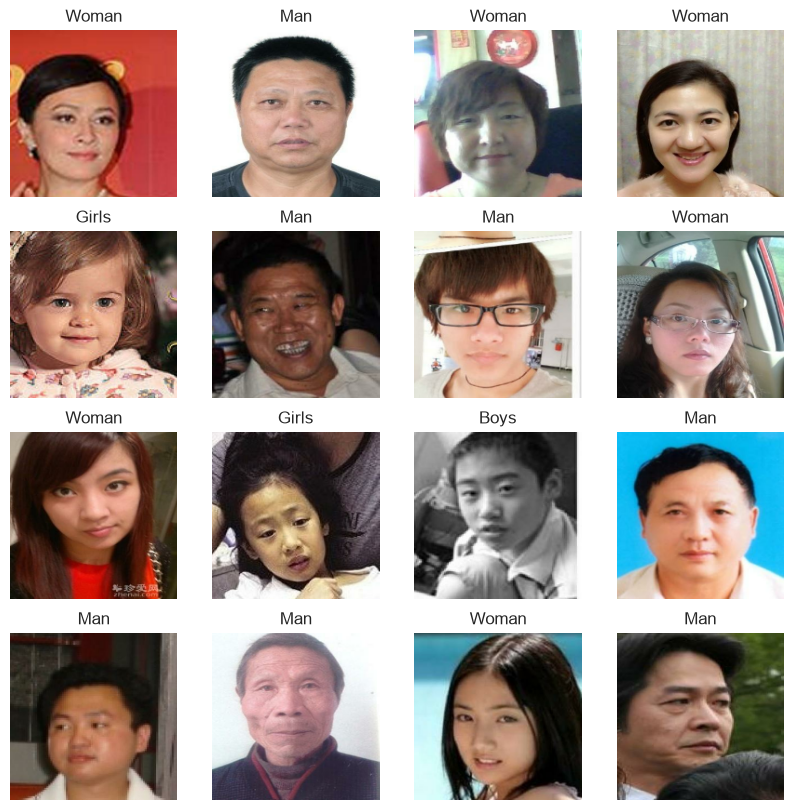

In [12]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

This section of the code is responsible for passing the dataset onto the Keras `Model.fit` method. The `image_batch` is a tensor that consits of the following values.

1.   The Batch Size (This is also the same value as the `labels_batch` shape
2.   The Dimesion of the image
3.   The amount of colour channels present in this image (since the RGB channel is being used, the value should be 3)


In [13]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


## Configuring the dataset from increased performance

This section of code is responsible for the application of the following two functions of the dataset. This is done to ensure that during the training process, when the datasets are fed into the model the `I/O` isn't blocked, this has the positive benefits of reducing system load and speeding up the training process exponentially.

The purpose of the `.cache()` function is to keep data loaded into the Tensorflow VM's memory after it's loaded of the disk. This is done in order to make the recall of the data far easier & faster. This is easily helpful during the evaluation process that occurs after each epoch.
If the dataset is too large to fit into memory, then this method  creates a performant on-disk cache, which is more efficient to read than many small files, this is akin to a swap partiation on linux, where addtional memory is storted tempoararly on the disk when memory is full.

The purpose of the `.prefetch()` function is to allow for the overlapping of  data preprocessing and model execution while training. This inturn dramaticlly speeds up the training process.

Addtionally, the `.shuffle()` function randomly shuffles the data around in order to remove training bias since the data was previously ordered sequentially.

In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Standardizing the dataset

This section of code is responsible for scaling the RGB channel values for each pixel from `[0,255]` to `[0,1]`. This makes training the model easier since the matrix multiplication calucations returns far easier numbers to work with.

In [15]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 0.9091177


# Creation of Training Model

## Creation of the Keras Sequential Convolution layers

This section of code is responsible for the creation of the hidden layers required for the Sequential Neural Model. Those layers are shown in the following digram below.  

The purpose of the 2D Convolution layer is to perform spatial convolution calculations on the images being fed into the model. This is done by creating a convolution kernel that takes the input from the `tf.data.Dataset` and produces a tensor of outputs. The `padding=same` argument results in the image being proceeding to ensure that the output has the same dimensions as the inputted image, this has been done to ensure that nothing in the image becomes distorted. In this model, There are 3 of these layers stacked on top of each other, this has been done to use the 'average' output of each of the layers to get a more accurate answer.

In each of these `tf.keras.layers.Conv2D` "blocks" there is a max pooling layer. The purpose of these layers is to perform the downsampling of the model's input with respect to the image's spatial dimensions. This is done in order to ensure that the model is correctly reading the image and is not being mistrained. The way that this process is done by taking the maximum values over an input window for each colour channel of the input image. This input window is shifted by the variable `strides` along each dimension present in the image. Since in the `tf.keras.layer.Conv2D` blocks the `padding=same` argument was used, the `output_shape` of the resized image is `output_shape = math.floor((input_shape - 1) / strides) + 1`. This results in the inputted images being sucessfully downsampled.

The purpose of the `tf.keras.layers.Dense` Dense layer is to calculate the weights for each category using the tensor of outputs from the 2D Convolution above. Once this has been done, a rectified linear activation function (also known as the ReLU) is used in order to transform the summed weighted input into a final output.

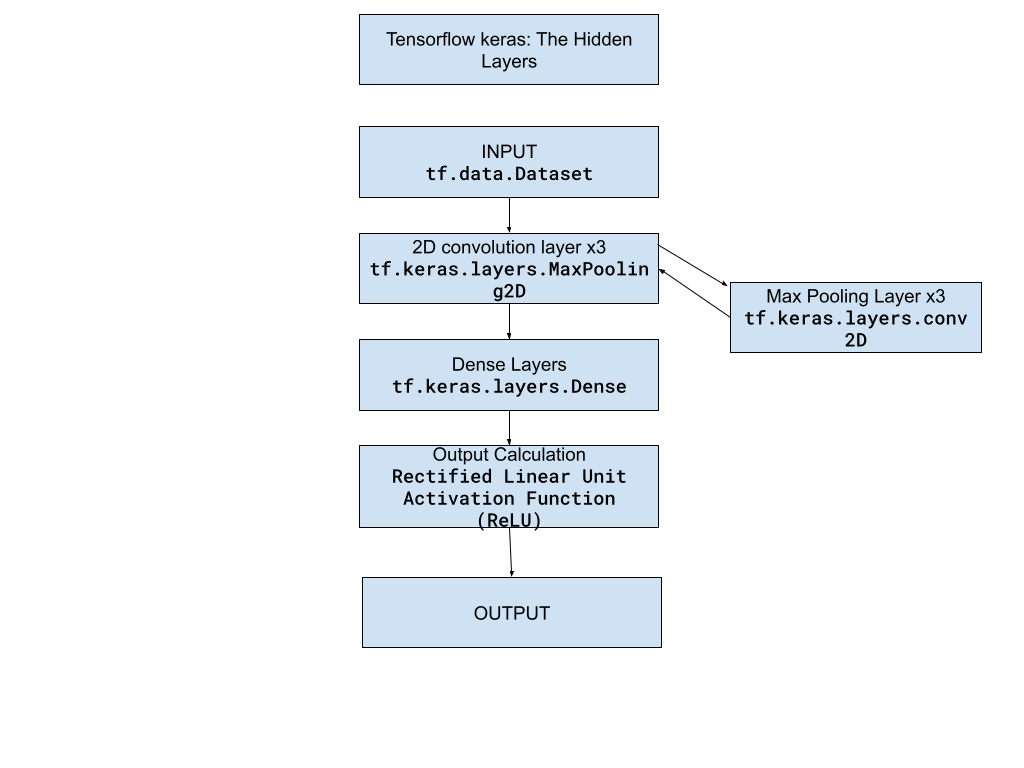

In [16]:
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

d:\User Data\Ruhan's Data\Documents\Code\Tensorflow-Image-Detection\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Compilation of model

This section of code is responsible for the actual compilation of the model. This is where the different layers are grouped sequentially into a single object with training/inference features such as Optimizers and loss functions.


In [17]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

This section of code is responsible for listing all of the layers that the present in the model alonside how much neurons they have.

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,156 (15.22 MB)

 Trainable params: 3,989,156 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

## Training the Model

This section of code is responsible for training the model using the Keras `model.fit` method

In [19]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10


d:\User Data\Ruhan's Data\Documents\Code\Tensorflow-Image-Detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


334/334 ━━━━━━━━━━━━━━━━━━━━ 55s 139ms/step - accuracy: 0.6049 - loss: 0.9641 - val_accuracy: 0.6580 - val_loss: 0.8491
Epoch 2/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 41s 123ms/step - accuracy: 0.6974 - loss: 0.7714 - val_accuracy: 0.7125 - val_loss: 0.7414
Epoch 3/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 43s 130ms/step - accuracy: 0.7583 - loss: 0.6260 - val_accuracy: 0.7444 - val_loss: 0.6675
Epoch 4/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 44s 133ms/step - accuracy: 0.8233 - loss: 0.4792 - val_accuracy: 0.7432 - val_loss: 0.7043
Epoch 5/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 44s 132ms/step - accuracy: 0.8781 - loss: 0.3347 - val_accuracy: 0.7530 - val_loss: 0.7529
Epoch 6/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 44s 132ms/step - accuracy: 0.9270 - loss: 0.2023 - val_accuracy: 0.7504 - val_loss: 0.9283
Epoch 7/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 44s 132ms/step - accuracy: 0.9630 - loss: 0.1137 - val_accuracy: 0.7260 - val_loss: 1.1065
Epoch 8/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 44s 133ms/step - accuracy: 0.9798 - loss: 0.0629 - val

## Visualize training results

Now that the model has been trained, the loss and accuracy of the training and validation sets can be plotted.


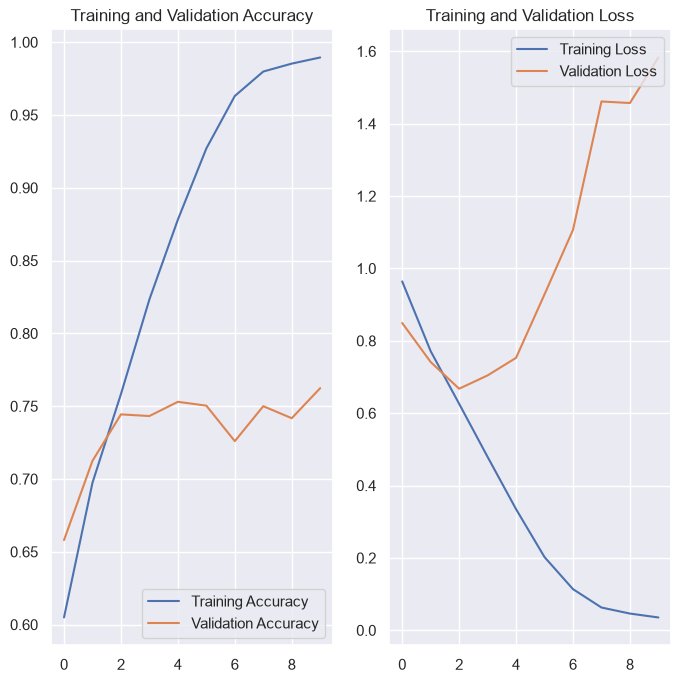

In [20]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

One of the noticable trends in these two graphs is the large disparity between `Training Accuracy` and `Validation Accuracy`. This indicates that there 

One of the reasons why there is a massive difference between `Training Accuracy` and `Validation Accuracy` is due to overfitting that may be present in the model. This is primarly caused by 

# Futher Model Optmization in order to reduce overfitting.

## Implementing Data Augmentation

One method that can be implented in order to mitigate the effects of overfitting is the use of Data augmentation. This is a technique to increase the diversity of a training set by applying random but realistic transformations, such as image rotation to copies of existing training images. This is done in order to expose the model to more aspects of the dataset so it can yield more accurate results.

The way that Data Augmentation was implemented in this model was using the standard method of implementation that is shown below:


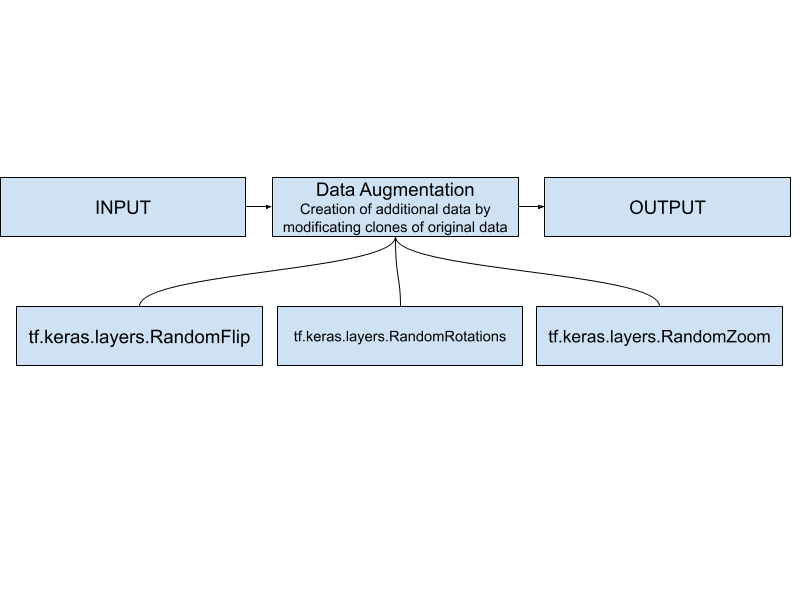

In [21]:
data_augmentation = tf.keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

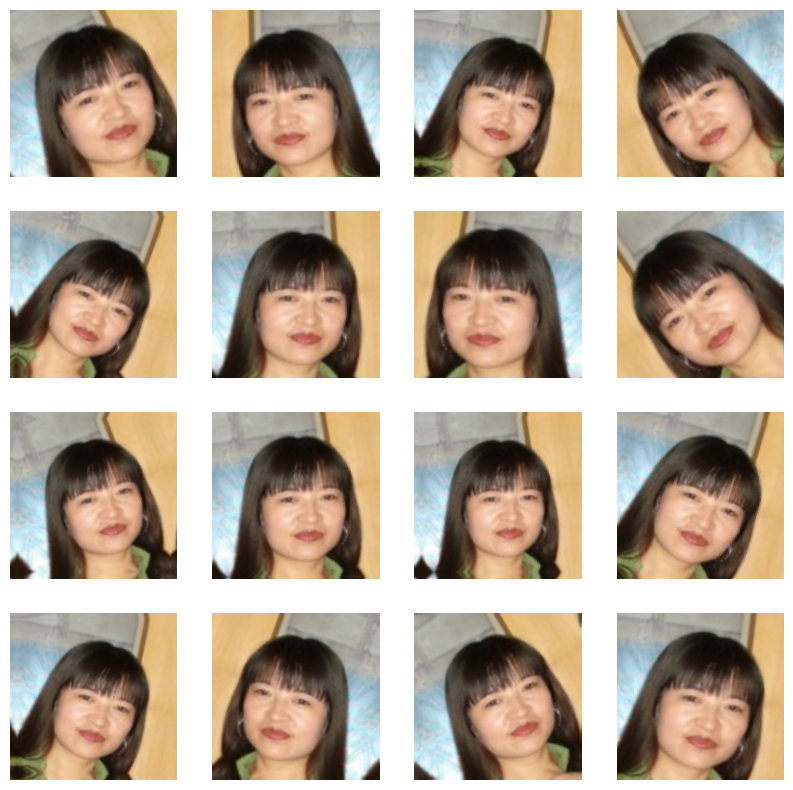

In [22]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(16):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

## Recreation of the Keras Sequential Convolution layers with the includation of Dropout layer

In [23]:
model = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, name="outputs")
])

## Recompilation of improved model

This section of code is responsible for the actual compilation of the model. This is where the different layers are grouped sequentially into a single object with training/inference features such as Optimizers and loss functions. This time however, the model will be compiled with a dropout layer

In [24]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

This section of code is responsible for listing all of the layers that the present in the model alonside how much neurons they have. Note how this summary has a dropout layer & an addtional 2 extra `conv2D` layers.

In [25]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,156 (15.22 MB)

 Trainable params: 3,989,156 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

## Training final Model

In [26]:
epochs = 15
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/15
334/334 ━━━━━━━━━━━━━━━━━━━━ 53s 153ms/step - accuracy: 0.5494 - loss: 1.0697 - val_accuracy: 0.6224 - val_loss: 0.9319
Epoch 2/15
334/334 ━━━━━━━━━━━━━━━━━━━━ 51s 153ms/step - accuracy: 0.6176 - loss: 0.9352 - val_accuracy: 0.6389 - val_loss: 0.8732
Epoch 3/15
334/334 ━━━━━━━━━━━━━━━━━━━━ 51s 153ms/step - accuracy: 0.6365 - loss: 0.9004 - val_accuracy: 0.6569 - val_loss: 0.8437
Epoch 4/15
334/334 ━━━━━━━━━━━━━━━━━━━━ 52s 155ms/step - accuracy: 0.6524 - loss: 0.8630 - val_accuracy: 0.6588 - val_loss: 0.8191
Epoch 5/15
334/334 ━━━━━━━━━━━━━━━━━━━━ 51s 153ms/step - accuracy: 0.6627 - loss: 0.8329 - val_accuracy: 0.6821 - val_loss: 0.7814
Epoch 6/15
334/334 ━━━━━━━━━━━━━━━━━━━━ 51s 153ms/step - accuracy: 0.6755 - loss: 0.8129 - val_accuracy: 0.7102 - val_loss: 0.7371
Epoch 7/15
334/334 ━━━━━━━━━━━━━━━━━━━━ 51s 153ms/step - accuracy: 0.6918 - loss: 0.7797 - val_accuracy: 0.7068 - val_loss: 0.7428
Epoch 8/15
334/334 ━━━━━━━━━━━━━━━━━━━━ 51s 153ms/step - accuracy: 0.7103 - loss: 0

## Visualzing final results

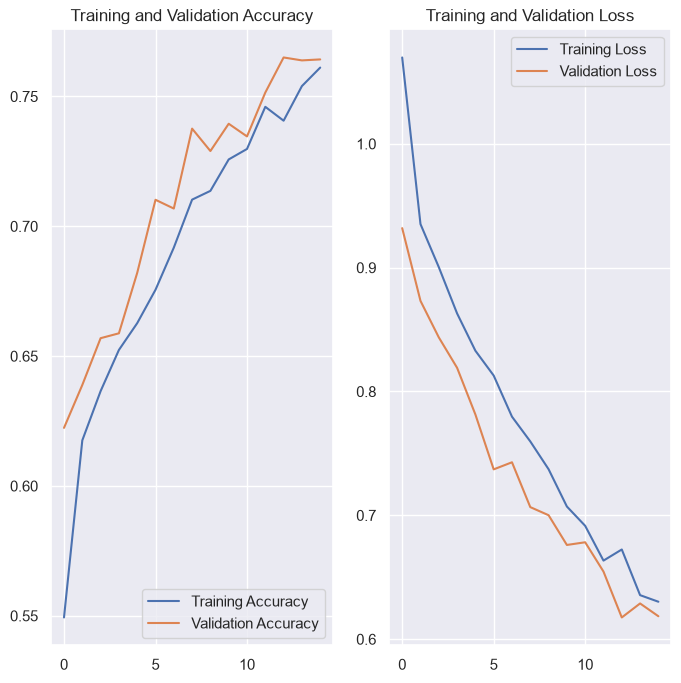

In [27]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Exporting Trained Models

## SavedModel

TensorFlow's standard and most portable export format, used when you want to serve your model, not just reload it in Python later. Think of it as "packaging your model to run somewhere else," like a production server or a cloud deployment pipeline. It's the format most external tools (TensorFlow Serving, TensorFlow.js converters, cloud platforms) expect by default.

In [28]:
model.export('saved_model_dir')

INFO:tensorflow:Assets written to: saved_model_dir\assets


INFO:tensorflow:Assets written to: saved_model_dir\assets


Saved artifact at 'saved_model_dir'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name='keras_tensor_15')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  1358399433872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956947984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956948368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956772432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956773392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956771664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956779536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956775120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956779152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956779728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956778768: TensorSpec(shape=

Loading Model back in

`loaded_model = tf.keras.layers.TFSMLayer('saved_model_dir', call_endpoint='serving_default')`

## .keras (Native Keras Format)

The modern, recommended way to save your model if you just want to pick up exactly where you left off, same architecture, same trained weights, ready to keep training or make predictions immediately. This is the one you'll use most often day-to-day: it's the "save my progress" button for your model.

In [29]:
model.save('my_model.keras')

Loading Model Back in

`loaded_model = tf.keras.models.load_model('my_model.keras')`

## HDF5 `(.h5)`

An older, single-file format for saving a full model — still widely supported and still shows up in a lot of existing tutorials and code online, so it's useful to recognize even if it's not the format you'd choose for a brand-new project today. Functionally similar to .keras, just the previous generation of the same idea.

In [30]:
model.save('my_model.h5')

## TFLite

A specialized, compressed version of your model designed to run on phones, microcontrollers, and other low-power/edge devices where a full desktop-sized model would be too slow or too large. If you've ever used an app that recognizes objects through your camera without an internet connection, there's a good chance a TFLite model is doing that work locally on your device.

In [31]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\RUHANS~1\AppData\Local\Temp\tmpm8iozldi\assets


INFO:tensorflow:Assets written to: C:\Users\RUHANS~1\AppData\Local\Temp\tmpm8iozldi\assets


Saved artifact at 'C:\Users\RUHANS~1\AppData\Local\Temp\tmpm8iozldi'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name='keras_tensor_15')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  1366956772432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956773392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956771664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956779536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956775120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956779152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956779728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956778768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956779344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1366956776848: TensorSpec(shape=(), dtype=tf.resource, name=None)
